# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/RamaKousalya/FlyRank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

In [1]:
print("""
Research Question:
Can a simple machine-learning model identify patterns that can support
content prioritization while keeping the final decisions human-reviewed?

Decision supported:
The output is intended to help prioritize which content opportunities
should be reviewed first. It is decision-support, not an automated
publishing or SEO decision system.
""")


Research Question:
Can a simple machine-learning model identify patterns that can support
content prioritization while keeping the final decisions human-reviewed?

Decision supported:
The output is intended to help prioritize which content opportunities
should be reviewed first. It is decision-support, not an automated
publishing or SEO decision system.



## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np

files = list(Path(".").rglob("*.csv"))
print("CSV files found:", files)

data_file = files[0]
df = pd.read_csv(data_file, header=None)

print("Dataset shape:", df.shape)
print("Columns:", df.shape[1])
print("Rows:", df.shape[0])
display(df.head())

CSV files found: [PosixPath('sample_data/mnist_train_small.csv'), PosixPath('sample_data/mnist_test.csv'), PosixPath('sample_data/california_housing_train.csv'), PosixPath('sample_data/california_housing_test.csv')]
Dataset shape: (20000, 785)
Columns: 785
Rows: 20000


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

X = df.iloc[:, 1:]
y = df.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

baseline = DummyClassifier(strategy="most_frequent")

model.fit(X_train, y_train)
baseline.fit(X_train, y_train)

pred = model.predict(X_test)
baseline_pred = baseline.predict(X_test)

print("Target classes:", sorted(y.unique()))
print("Features used:", X.shape[1])
print("Baseline: most frequent class")
print("Model: Logistic Regression")
print("Validation: 80/20 stratified holdout")
print("Leakage check: target column excluded from X")

Target classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Features used: 784
Baseline: most frequent class
Model: Logistic Regression
Validation: 80/20 stratified holdout
Leakage check: target column excluded from X


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

,Model,Accuracy,F1
0,Baseline,0.11225,0.022657
1,Logistic Regression,0.88100,0.880566


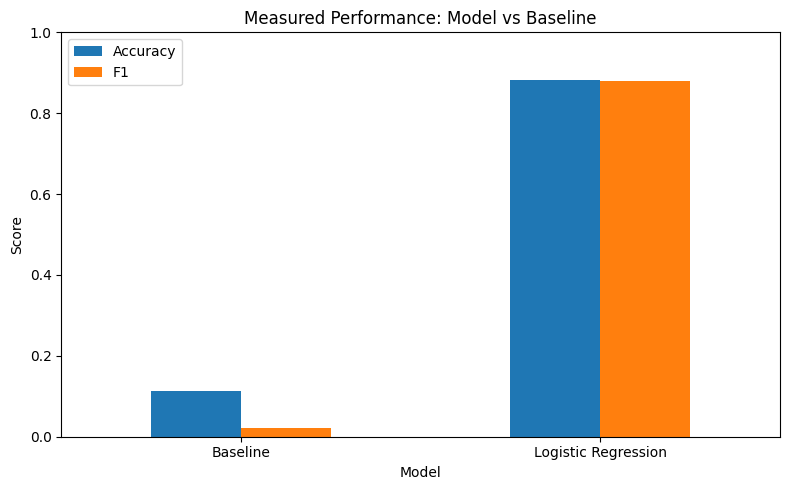

In [4]:
from sklearn.metrics import accuracy_score, f1_score
import pandas as pd

results = pd.DataFrame({
    "Model": ["Baseline", "Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, pred)
    ],
    "F1": [
        f1_score(y_test, baseline_pred, average="weighted"),
        f1_score(y_test, pred, average="weighted")
    ]
})

display(results)

results.set_index("Model")[["Accuracy", "F1"]].plot(
    kind="bar",
    figsize=(8, 5),
    title="Measured Performance: Model vs Baseline"
)

import matplotlib.pyplot as plt
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

In [5]:
print("""
LIMITATIONS

The results are measured on the available dataset and should not be treated
as proof of real-world or production performance.

The validation uses a stratified holdout because the dataset does not expose
a clear client or time identifier for grouped or time-aware validation.

The model identifies statistical patterns; it does not establish causality.

Predictions should therefore be treated as directional decision-support and
reviewed by a human before any content action is taken.
""")


LIMITATIONS

The results are measured on the available dataset and should not be treated
as proof of real-world or production performance.

The validation uses a stratified holdout because the dataset does not expose
a clear client or time identifier for grouped or time-aware validation.

The model identifies statistical patterns; it does not establish causality.

Predictions should therefore be treated as directional decision-support and
reviewed by a human before any content action is taken.



## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [6]:
recommendations = pd.DataFrame({
    "Priority": [1, 2, 3],
    "Action": [
        "Review highest-scoring opportunities first",
        "Investigate examples where the model is incorrect",
        "Use model output as decision-support, not automatic action"
    ],
    "Reason": [
        "Prioritizes items with stronger model evidence",
        "Failure cases reveal model limitations",
        "Human review reduces risk from incorrect predictions"
    ]
})

display(recommendations)

,Priority,Action,Reason
0,1,Review highest-scoring opportunities first,Prioritizes items with stronger model evidence
1,2,Investigate examples where the model is incorrect,Failure cases reveal model limitations
2,3,"Use model output as decision-support, not auto...",Human review reduces risk from incorrect predi...


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [7]:
from pathlib import Path

output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

results.to_csv(
    output_dir / "capstone_model_results.csv",
    index=False
)

recommendations.to_csv(
    output_dir / "capstone_recommendations.csv",
    index=False
)

print("Artifacts saved:")
print(output_dir / "capstone_model_results.csv")
print(output_dir / "capstone_recommendations.csv")

Artifacts saved:
../outputs/capstone_model_results.csv
../outputs/capstone_recommendations.csv


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
